In [1]:
import sys
import torch
sys.path.append("/global/u1/r/rmastand/mlpf-ssl/particlemind")
#!{sys.executable} -m pip install awkward

import os

# Force Hugging Face datasets cache to local scratch (avoid NFS filelock hangs)
os.environ["HF_DATASETS_CACHE"] = f"/tmp/{os.environ['USER']}/hf_datasets_cache"
os.environ["HF_HOME"] = f"/tmp/{os.environ['USER']}/hf_home"  # optional, safer for configs



In [2]:
import numpy as np
import matplotlib.pyplot as plt


import awkward as ak
from src.data.CaloHitDataset import CaloHitDataset
from src.data.CaloPatchDataset import CaloPatchDataset


from src.models.vqvae import VQVAELightning
from src.data.utils import CollaterPatch, CollaterHits
from torch.utils.data import DataLoader
from tqdm import tqdm


In [3]:
num_files = 1

E_min = 0.001
pad = 10000

data_type = "hit"

if data_type == "hit":
    collater = CollaterHits(empty_key="calo_hit_features", variable_size_keys="all", pad=pad)
    loader = CaloHitDataset

elif data_type == "patch":
    collator = CollaterPatch
    loader = CaloPatchDataset


In [4]:
path_to_embedder_checkpoint = "/pscratch/sd/r/rmastand/particlemind/vqvae_training/best_models/embedder_hit_vqvae_val_loss_epoch=11.ckpt"


# Apply embedder to original data

tokenize and reconstruct

In [5]:
# load in embedder

embedder = VQVAELightning.load_from_checkpoint(
           path_to_embedder_checkpoint,
        )


# kinematic features
kinematic_features_truth = {i:ak.Array([]) for i in range(4)}
kinematic_features_reco = {i:ak.Array([]) for i in range(4)}
z_orig, z_aug = [], []
tokens = ak.Array([])
        


for n in range(num_files):



    file_dataset = loader(
        "ttbar_pu0_calo_hits",
        "train",
        start_idx=n*100,
        stop_idx=(n+1)*100,
        train_fraction=1.0,
        E_min=E_min,
        augment_dataset=True
    )

    file_loader = DataLoader(
        file_dataset,
        batch_size=2,
        collate_fn=collater,
        num_workers=0, # must be zero otherwise events are duplicated
     shuffle=False
    )

  
    for i, x_batch in tqdm(enumerate(file_loader)):

        if data_type == "hit":

            features_batch = x_batch["calo_hit_features"].to(embedder.device)
            features_augmented_batch =  x_batch["calo_hit_features_augmented"].to(embedder.device)
            mask_batch = x_batch["mask"].to(embedder.device)

      
            with torch.no_grad():
                x_particle_reco, vq_out, z_embed = embedder.forward(None, features_batch, mask_batch) # batch not used
                x_particle_augmented, vq_out_augmented, z_embed_augmented = embedder.forward(None, features_augmented_batch, mask_batch)
                

     
        elif data_type == "patch":
            with torch.no_grad():
                e, e_reco, x_chunks, x_reco_chunks, vq_out = embedder.forward(x_batch, None, None)

            print(e.shape)
            print(e_reco.shape)
            print(x_chunks.shape)
            print(x_reco_chunks.shape)
            
        
        for row in range(x_particle_reco.shape[0]):

            
            features_event = features_batch[row]
            reco_event = x_particle_reco[row].detach().cpu().numpy()
            mask_event = mask_batch[row].int().detach().cpu().numpy()
            labels_event = x_batch["hit_labels"][row]

            for i in range(4):
                kinematic_features_truth[i] = ak.concatenate([kinematic_features_truth[i], ak.Array([features_event[:,i][mask_event==1]])], axis = 0)
                kinematic_features_reco[i] = ak.concatenate([kinematic_features_reco[i], ak.Array([reco_event[:,i][mask_event==1]])], axis = 0)
                

            z_orig.append(z_embed[row].detach().cpu())
            z_aug.append(z_embed_augmented[row].detach().cpu())

            if vq_out is not None:
                tokens_event = vq_out["q"][row].detach().cpu().numpy().reshape(-1,)
                tokens =  ak.concatenate([tokens, ak.Array([tokens_event[mask_event==1]])], axis = 0)


                       


/global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/lightning/pytorch/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.5.5, which is newer than your current Lightning version: v2.5.0.post0
0it [00:00, ?it/s]

Resolving data files:   0%|          | 0/1000 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1000 [00:00<?, ?it/s]

50it [01:16,  1.53s/it]


In [6]:
# shape: # events, num hits, num dimensions

# create event-level embedding by taking the sum over all the hits

event_embeddings_orig = torch.stack([torch.mean(z, axis=0) for z in z_orig])
event_embeddings_aug = torch.stack([torch.mean(z, axis=0) for z in z_aug])


In [7]:
!pip install umap-learn

Defaulting to user installation because normal site-packages is not writeable
DEPRECATION: Loading egg at /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/torchvision-0.21.0+7af6987-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/setuptools-75.8.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/pillow-11.1.0-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package install

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import umap

def plot_umap_side_by_side(embeddings_orig, embeddings_aug):
    # Move to CPU + convert to numpy
    if isinstance(embeddings_orig, torch.Tensor):
        embeddings_orig = embeddings_orig.detach().cpu().numpy()
    if isinstance(embeddings_aug, torch.Tensor):
        embeddings_aug = embeddings_aug.detach().cpu().numpy()

    # Fit UMAP on combined data for consistent projection space
    combined = np.concatenate([embeddings_orig, embeddings_aug], axis=0)

    reducer = umap.UMAP(n_components=2, random_state=42)
    embedding_2d = reducer.fit_transform(combined)

    # Split back
    n = embeddings_orig.shape[0]
    emb_orig_2d = embedding_2d[:n]
    emb_aug_2d = embedding_2d[n:]

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(emb_orig_2d[:, 0], emb_orig_2d[:, 1], s=10)
    axes[0].set_title("Original Embeddings")
    axes[0].set_xlabel("UMAP-1")
    axes[0].set_ylabel("UMAP-2")

    axes[1].scatter(emb_aug_2d[:, 0], emb_aug_2d[:, 1], s=10)
    axes[1].set_title("Augmented Embeddings")
    axes[1].set_xlabel("UMAP-1")
    axes[1].set_ylabel("UMAP-2")

    plt.tight_layout()
    plt.show()


    plt.figure()
    for i in range(10):
        plt.scatter(emb_orig_2d[i, 0], emb_orig_2d[i, 1], s=10, color=f"C{i}", marker="o")
        plt.scatter(emb_aug_2d[i, 0], emb_aug_2d[i, 1], s=10, color=f"C{i}", marker="*")
    plt.show()

/global/homes/r/rmastand/.local/perlmutter/pytorch2.6.0/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


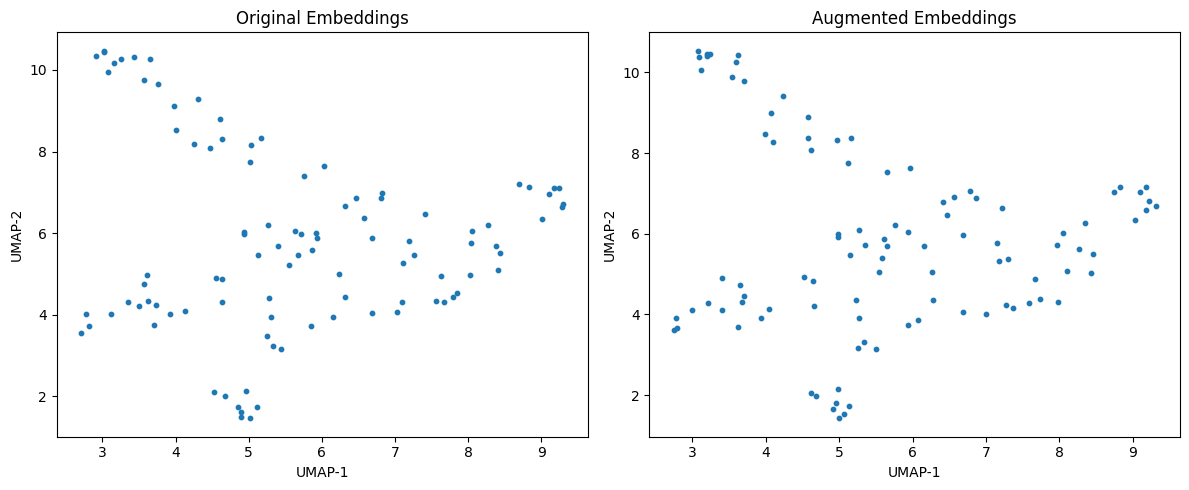

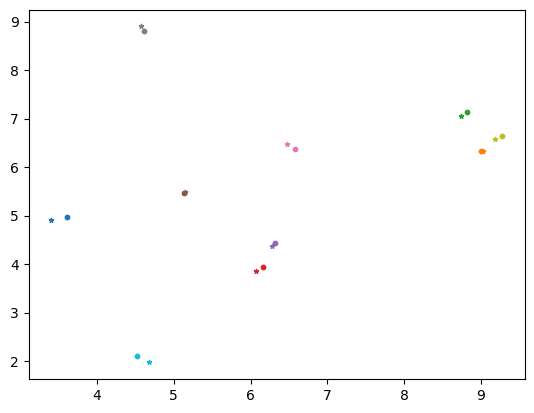

In [18]:
plot_umap_side_by_side(event_embeddings_orig, event_embeddings_aug)

# Plot multiple events


In [10]:
position_lim = 0.5
e_lim = -1, 1

## x, y, z, e (1d)

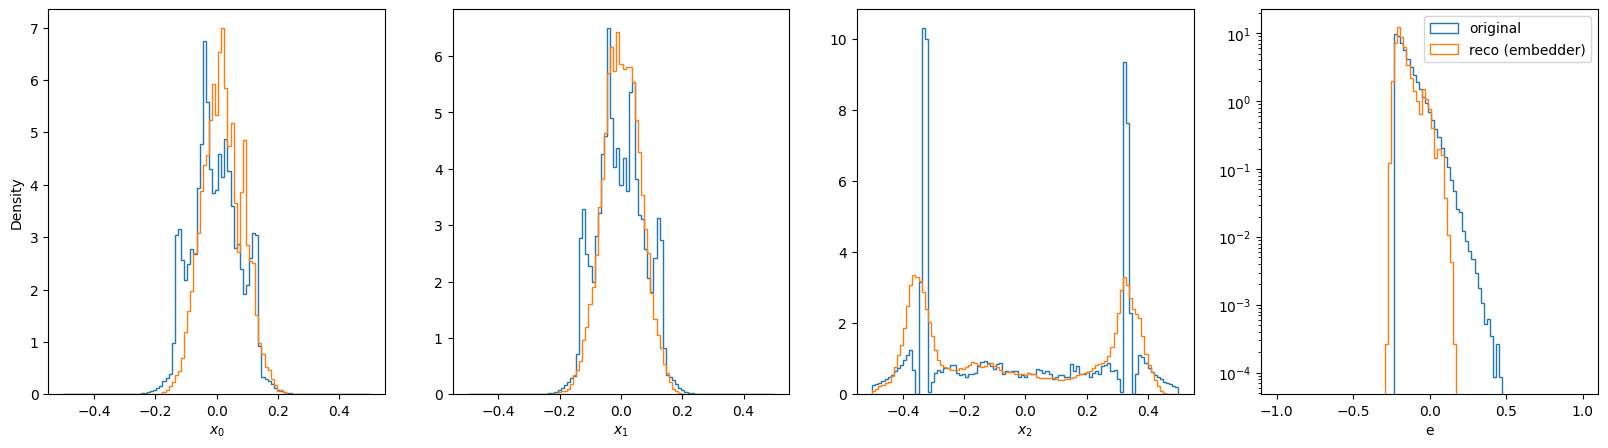

In [11]:
# calo

nbins = 100

fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(3):

    ax[i].hist(ak.flatten(kinematic_features_truth[i]), bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "original", density=True)
    ax[i].hist(ak.flatten(kinematic_features_reco[i]), bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "reco (embedder)", density=True)

    ax[i].set_xlabel(f"$x_{i}$")

ax[3].hist(ak.flatten(kinematic_features_truth[3]), bins = np.linspace(e_lim[0], e_lim[1], nbins), histtype = "step", label = "original", density=True)
ax[3].hist(ak.flatten(kinematic_features_reco[3]), bins = np.linspace(e_lim[0], e_lim[1], nbins), histtype = "step", label = "reco (embedder)", density=True)
ax[3].set_xlabel("e")
ax[3].set_yscale("log")
ax[3].legend()

ax[0].set_ylabel("Density")

plt.show()

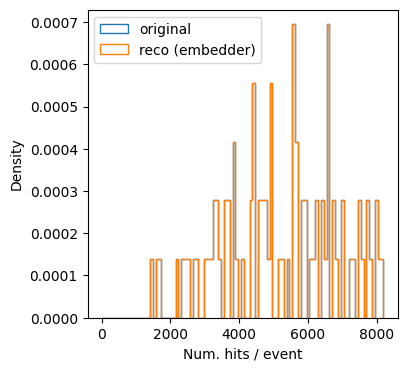

In [12]:
# number of hits

fig, ax = plt.subplots(1, 1, figsize = (4, 4))
ax.hist([len(event) for event in kinematic_features_truth[0]], bins = np.linspace(0, 8192, nbins), histtype = "step", label = "original", density=True)
ax.hist([len(event) for event in kinematic_features_reco[0]], bins = np.linspace(0, 8192, nbins), histtype = "step", label = "reco (embedder)", density=True)
ax.set_xlabel("Num. hits / event")
ax.set_ylabel("Density")
ax.legend()
plt.show()

# E resolution

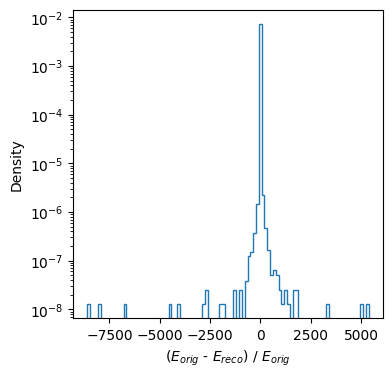

'\n\nfig, ax = plt.subplots(1, 1, figsize = (4, 4))\n\n\nunique_labels = [np.unique(l.to_numpy()) for l in hit_labels]\nhit_clusters_true, hit_clusters_reco = [], []\nfor event_i, hit_labels_event_i in enumerate(hit_labels):\n    for unique_label_event_i in unique_labels[event_i]:\n        mask = hit_labels_event_i == unique_label_event_i\n   \n        hit_clusters_true.append(np.sum(features_e[event_i][mask]))\n        hit_clusters_reco.append(np.sum(reco_e[event_i][mask]))\n\nax.hist((np.array(hit_clusters_true) - np.array(hit_clusters_reco))/np.array(hit_clusters_true), bins=nbins, density=True, histtype="step", linewidth=2)\nax.set_xlabel( "$E_{true} - E_{reco}$  / $E_{reco}$ per cluster")\nax.set_ylabel("Density")\nax.set_ylabel("Density")\nax.set_yscale("log")\n#ax.legend(loc="upper right")\n'

In [13]:
fig, ax = plt.subplots(1, 1, figsize = (4, 4))
ax.hist((ak.flatten(kinematic_features_truth[3]) - ak.flatten(kinematic_features_reco[3]))/ak.flatten(kinematic_features_truth[3]), bins = nbins, histtype = "step", label = "original", density=True)
ax.set_xlabel("($E_{orig}$ - $E_{reco}$) / $E_{orig}$")
ax.set_ylabel("Density")
ax.set_yscale("log")
plt.show()


"""

fig, ax = plt.subplots(1, 1, figsize = (4, 4))


unique_labels = [np.unique(l.to_numpy()) for l in hit_labels]
hit_clusters_true, hit_clusters_reco = [], []
for event_i, hit_labels_event_i in enumerate(hit_labels):
    for unique_label_event_i in unique_labels[event_i]:
        mask = hit_labels_event_i == unique_label_event_i
   
        hit_clusters_true.append(np.sum(features_e[event_i][mask]))
        hit_clusters_reco.append(np.sum(reco_e[event_i][mask]))

ax.hist((np.array(hit_clusters_true) - np.array(hit_clusters_reco))/np.array(hit_clusters_true), bins=nbins, density=True, histtype="step", linewidth=2)
ax.set_xlabel( "$E_{true} - E_{reco}$  / $E_{reco}$ per cluster")
ax.set_ylabel("Density")
ax.set_ylabel("Density")
ax.set_yscale("log")
#ax.legend(loc="upper right")
"""

# Plot single events

## x, y, z, e (1d)

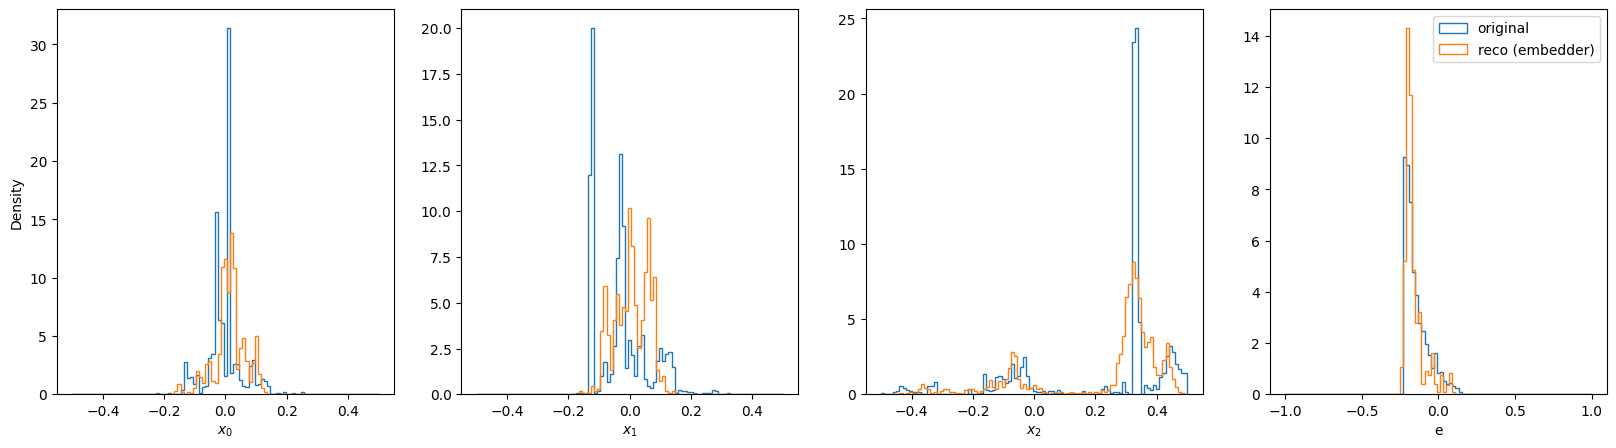

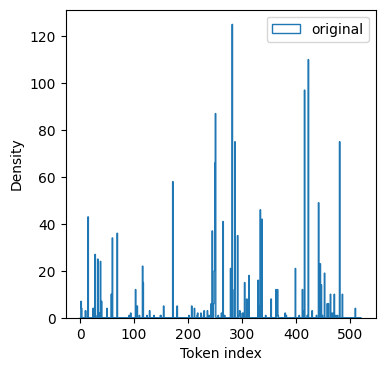

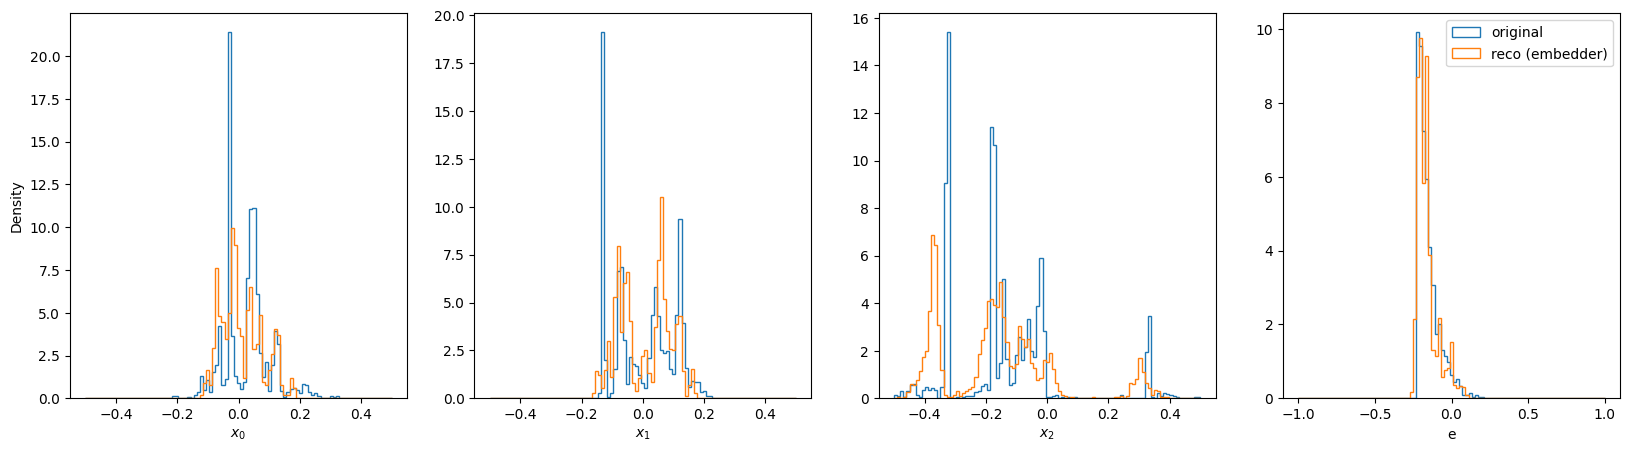

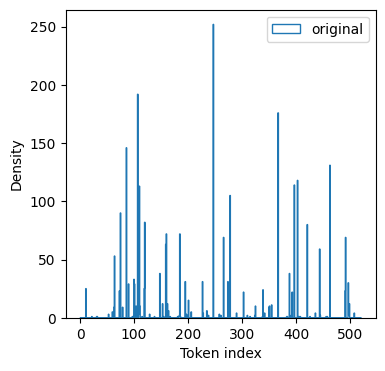

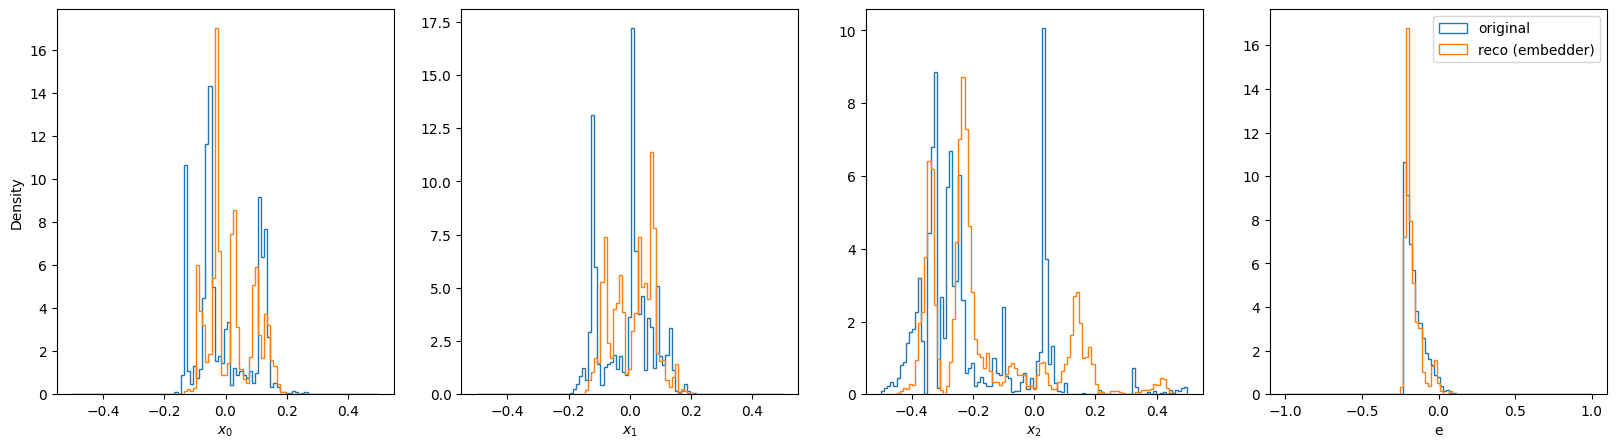

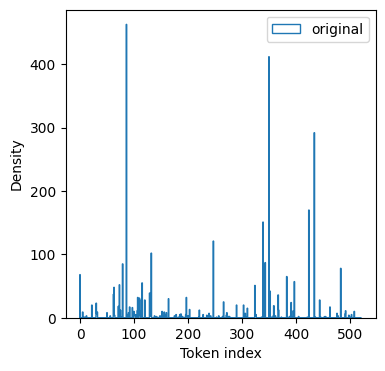

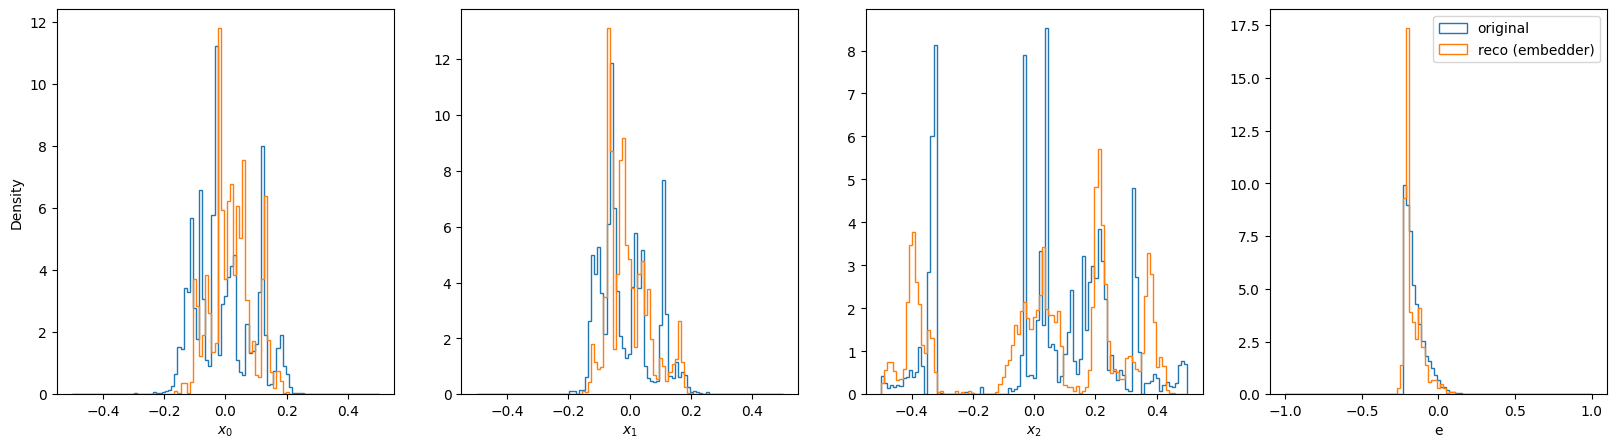

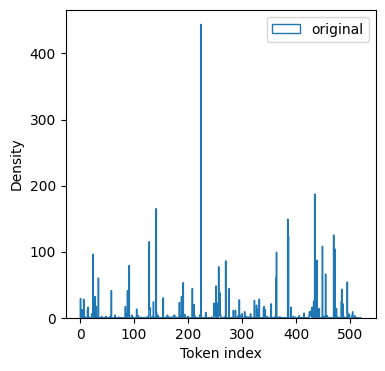

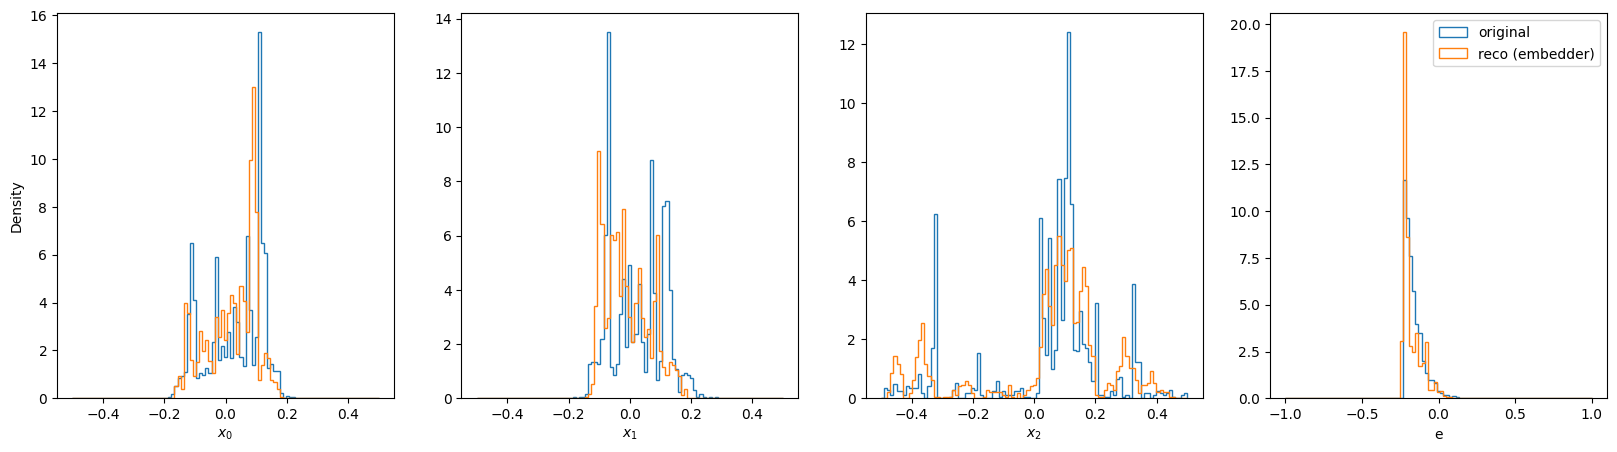

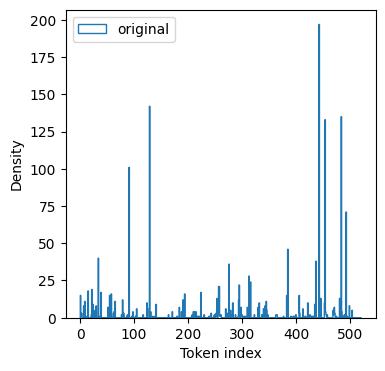

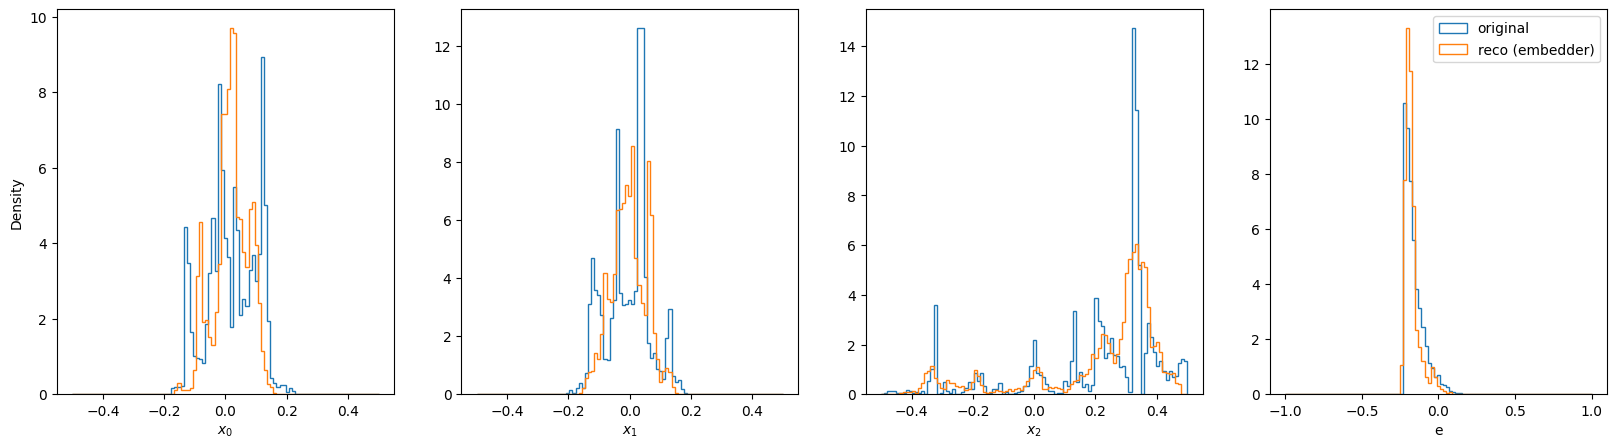

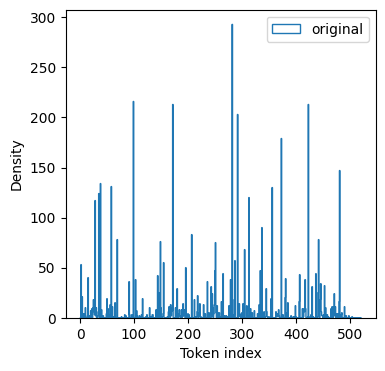

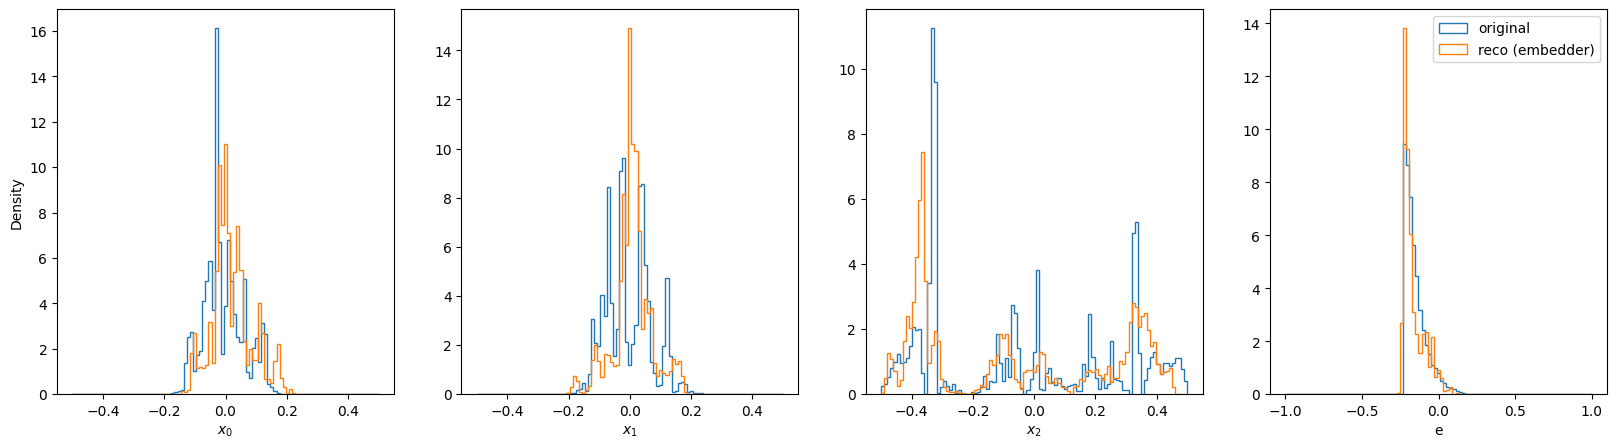

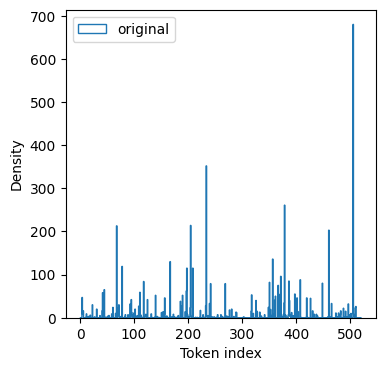

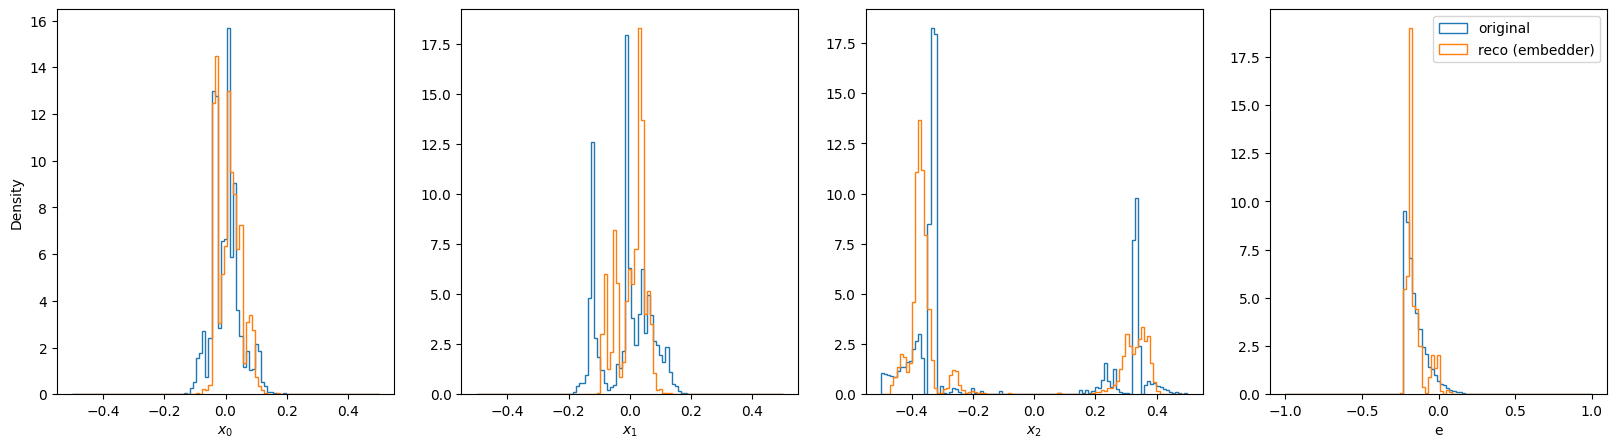

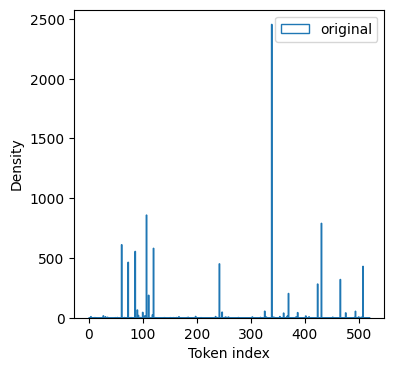

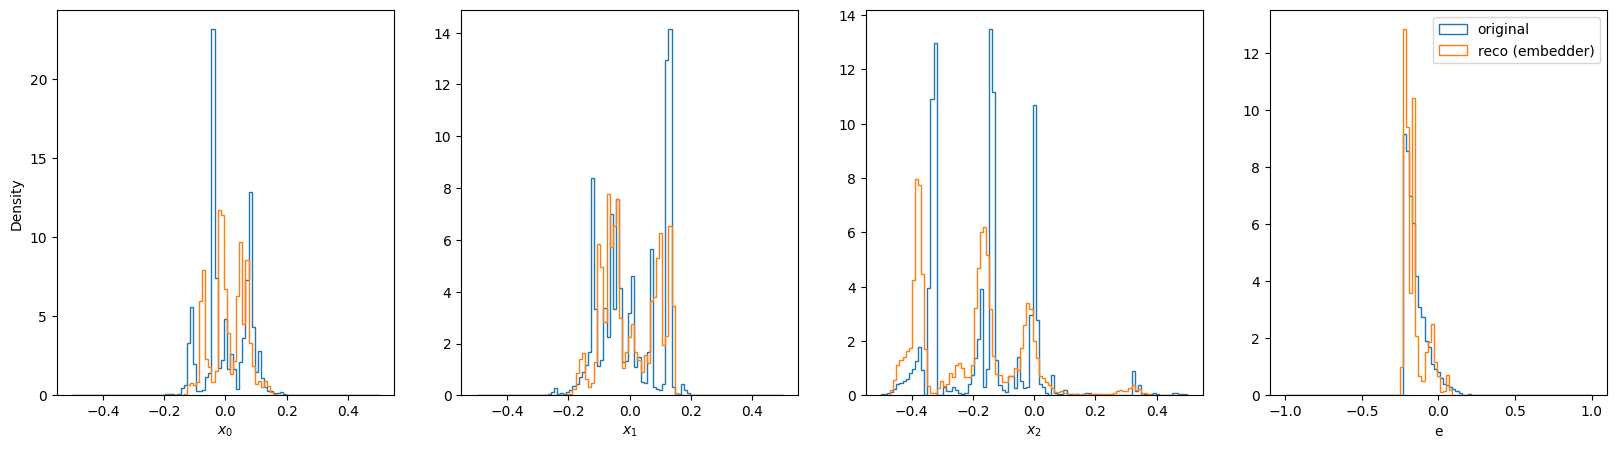

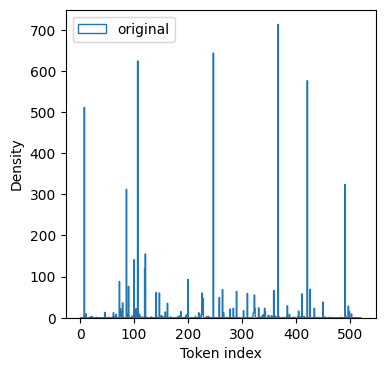

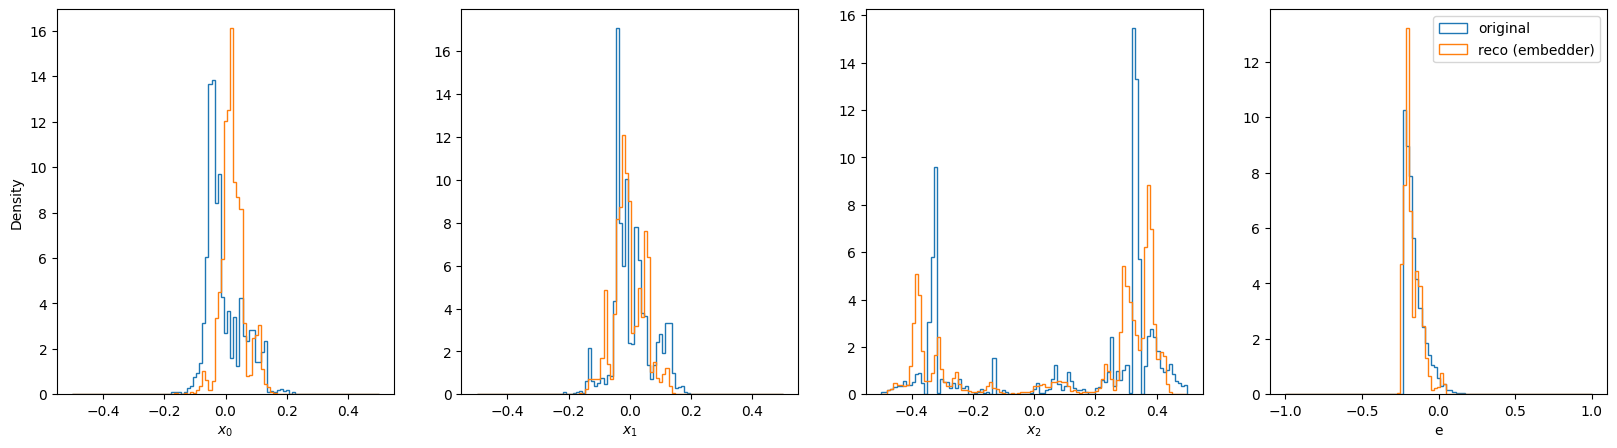

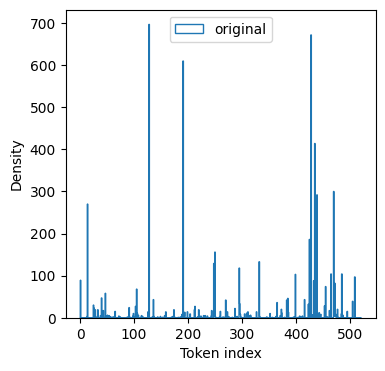

In [14]:
nbins = 100


for event_i in range(10):

    fig, ax = plt.subplots(1, 4, figsize = (20, 5))

    for i in range(3):

        ax[i].hist(kinematic_features_truth[i][event_i], bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "original", density=True)
        ax[i].hist(kinematic_features_reco[i][event_i], bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "reco (embedder)", density=True)

        ax[i].set_xlabel(f"$x_{i}$")
    

    ax[3].hist(kinematic_features_truth[3][event_i], bins = np.linspace(e_lim[0], e_lim[1], nbins), histtype = "step", label = "original", density=True)
    ax[3].hist(kinematic_features_reco[3][event_i], bins = np.linspace(e_lim[0], e_lim[1], nbins), histtype = "step", label = "reco (embedder)", density=True)

    ax[3].set_xlabel("e")
    ax[3].legend()

    ax[0].set_ylabel("Density")

    
    plt.show()


    fig, ax = plt.subplots(1, 1, figsize = (4, 4))
    ax.hist(tokens[event_i], bins = np.arange(-0.5, 522.5, 1), histtype = "step", label = "original")
    ax.legend()
    ax.set_xlabel("Token index")
    ax.set_ylabel("Density")
    plt.show()

## 2d positions

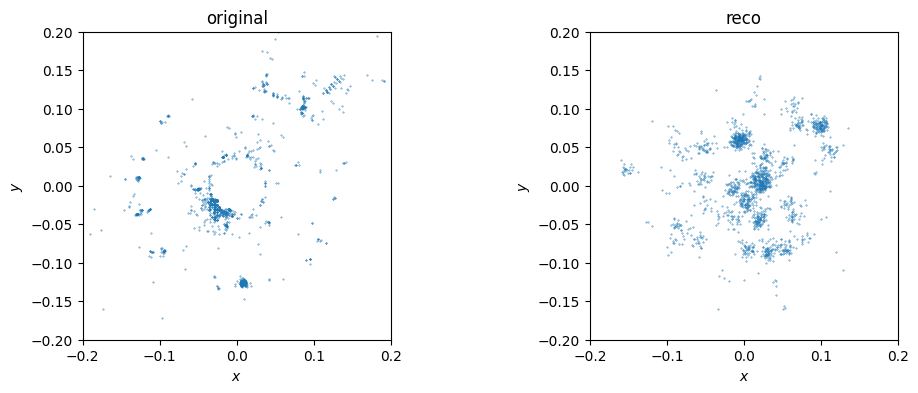

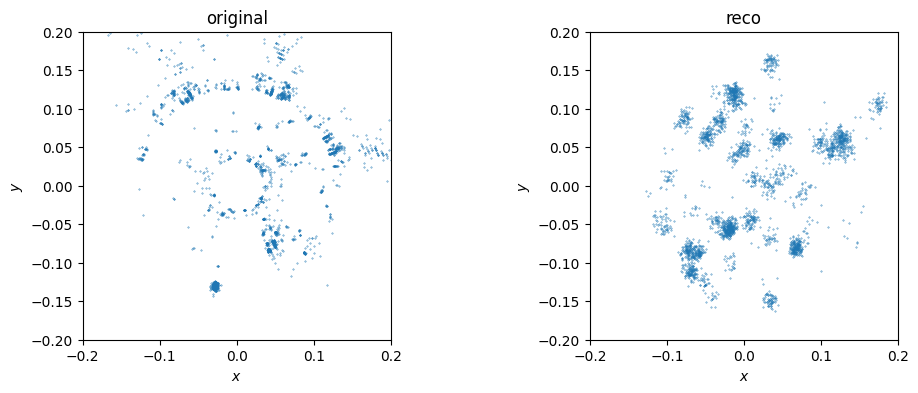

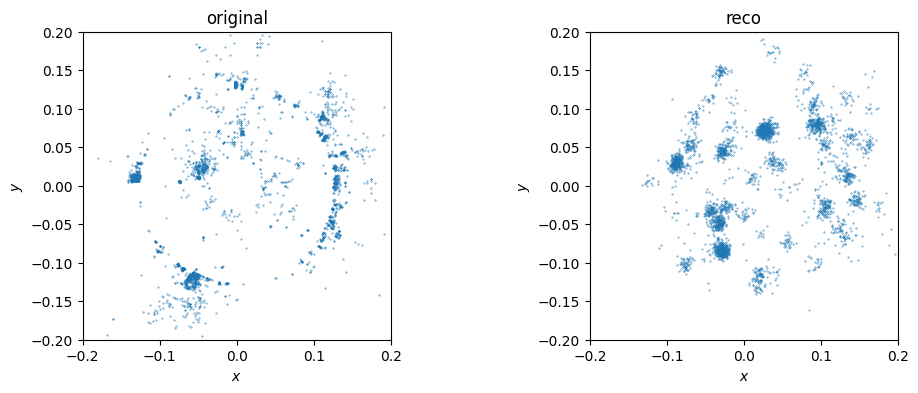

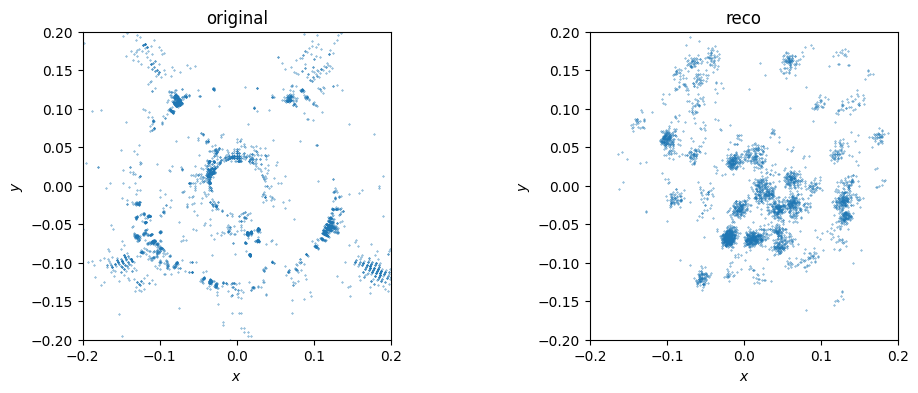

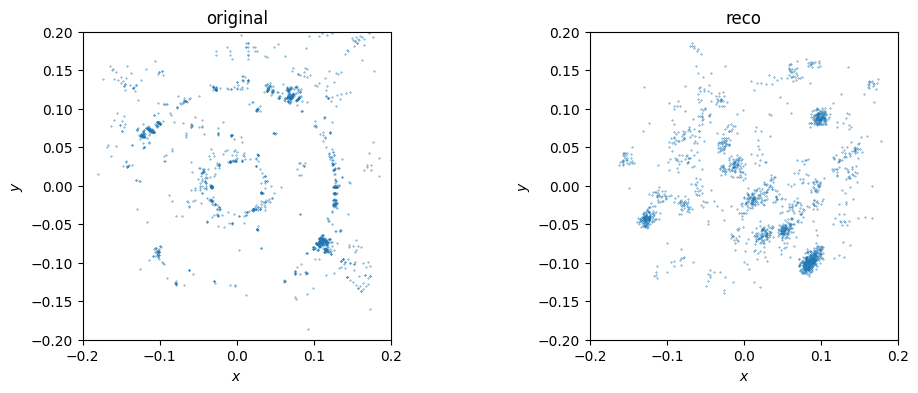

In [15]:
detector_index = 9

plot_lim = 0.2
s = 0.1

for i in range(5):

    fig, ax = plt.subplots(1, 2, figsize = (12, 4))

    for a in ax:
        a.set_box_aspect(1)   # <-- TRUE SQUARE SUBPLOT BOX
        a.set_xlim(-plot_lim, plot_lim)
        a.set_ylim(-plot_lim, plot_lim)

    
    ax[0].scatter(kinematic_features_truth[0][i], kinematic_features_truth[1][i], s = s)
    ax[0].set_xlabel(f"$x$")
    ax[0].set_ylabel(f"$y$")
    ax[0].set_title("original")
    
    ax[1].scatter(kinematic_features_reco[0][i], kinematic_features_reco[1][i], s = s)
    ax[1].set_xlabel(f"$x$")
    ax[1].set_ylabel(f"$y$")
    ax[1].set_title("reco")


    
    plt.show()




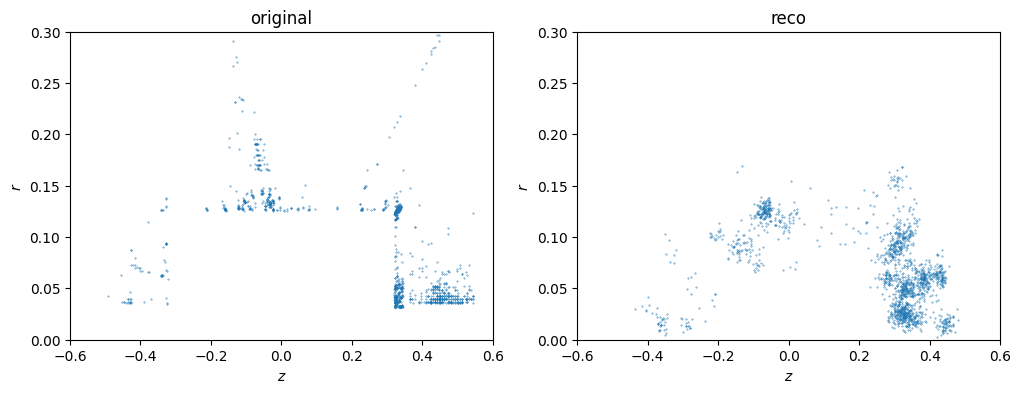

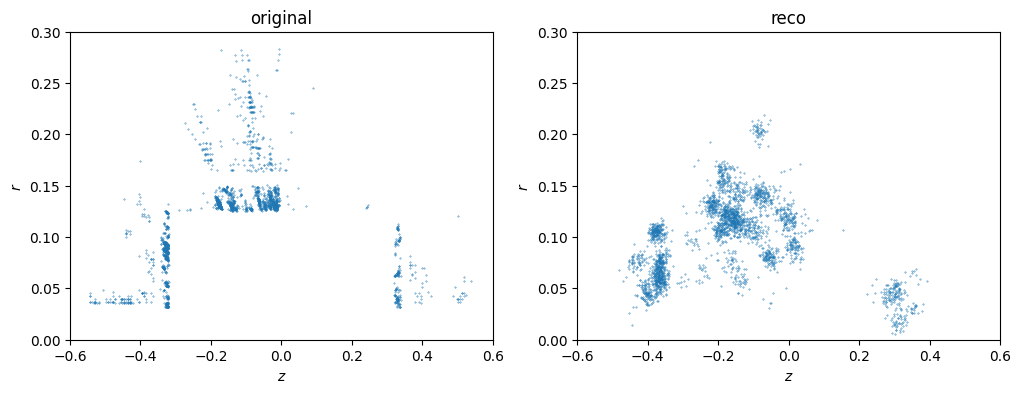

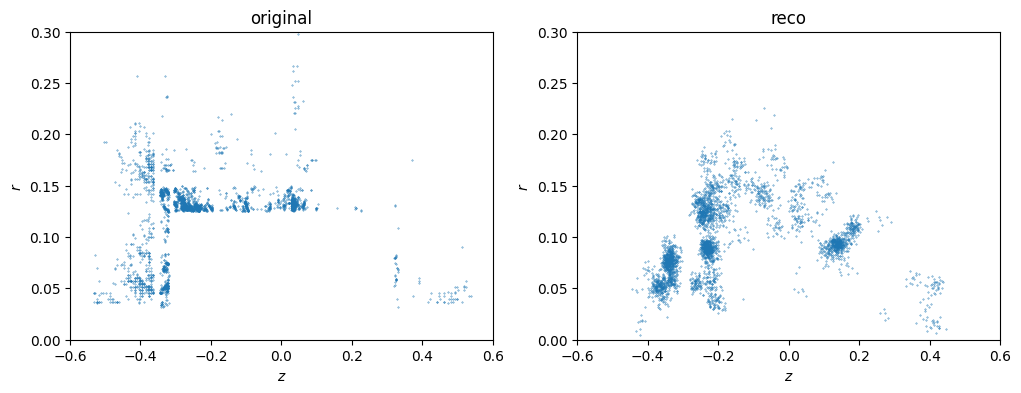

In [16]:
r_lim = 0., 0.3
z_lim = 0.6

for i in range(3):

    fig, ax = plt.subplots(1, 2, figsize = (12, 4))

    #for a in ax:
     #   a.set_box_aspect(1)   # <-- TRUE SQUARE SUBPLOT BOX
    #    a.set_xlim(-position_lim, position_lim)
     #   a.set_ylim(-position_lim, position_lim)

    tmp_r = np.sqrt(kinematic_features_truth[0][i]**2 + kinematic_features_truth[1][i]**2)
    ax[0].scatter(kinematic_features_truth[2][i], tmp_r, s = s)
    ax[0].set_xlabel(f"$z$")
    ax[0].set_ylabel(f"$r$")
    ax[0].set_xlim(-z_lim, z_lim)
    ax[0].set_ylim(r_lim)
    ax[0].set_title("original")

    tmp_r = np.sqrt(kinematic_features_reco[0][i]**2 + kinematic_features_reco[1][i]**2)
    ax[1].scatter(kinematic_features_reco[2][i], tmp_r, s = s)
    ax[1].set_xlabel(f"$z$")
    ax[1].set_ylabel(f"$r$")
    ax[1].set_xlim(-z_lim, z_lim)
    ax[1].set_ylim(r_lim)
    ax[1].set_title("reco")


    
    plt.show()




# Apply augmentations and visualize latent space 